Agentic RAG = Traditional RAG + Agents with tools

In [ ]:
# import os
# from dotenv import load_dotenv

# load_dotenv()

# os.getenv("GEMINI_API_KEY")
# os.getenv("GROQ_API_KEY")
# os.getenv("OPEN_ROUTER_API_KEY")
# os.getenv("LANGSMITH_API_KEY")

In [2]:
from langchain_community.document_loaders import WebBaseLoader   # Can read content directly from website
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

C:\Users\yashs\AppData\Local\Temp\ipykernel_24660\634365189.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader   # Can read content directly from website
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
urls=[
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceCheckpointersStoresFault toleranceEvent stre

In [4]:
list = [item for i in docs for item in i]


splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 100)
splits = splitter.split_documents(list)
print(splits[:2])

vectordb = FAISS.from_documents(
documents = splits,
embedding = HuggingFaceEmbeddings(model="BAAI/bge-small-en-v1.5"))

retriever = vectordb.as_retriever()

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content="LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceCheckpointersStoresFault toleranceEvent stream

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [5]:
print("Number of original documents:", len(list))
print("Number of chunks:", len(splits))

Number of original documents: 3
Number of chunks: 110


In [6]:
retriever.invoke("Tell me about langgraph")

[Document(id='40c0cd1c-12ea-4e7f-9b77-effec613aa3f', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content="LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceChe

In [7]:
from langchain_core.tools import create_retriever_tool
retriever_tool_langgraph = create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",        # Name of the tool
    "Search and run information about Langgraph"     # LLM agent will see both arguments
)

In [8]:
retriever_tool_langgraph

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x0000021587EA0720>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x00000215FBC05E40>)

#### Separate vector DB will be created for langchain

In [9]:
langchain_urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/event-streaming",
    "https://docs.langchain.com/oss/python/langchain/guardrails"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgent

In [10]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstorelangchain=FAISS.from_documents(
    documents=doc_splits,
    embedding=HuggingFaceEmbeddings(model="BAAI/bge-small-en-v1.5"))


retrieverlangchain=vectorstorelangchain.as_retriever()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [11]:
from langchain_core.tools import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [12]:
tools=[retriever_tool_langgraph,retriever_tool_langchain]

In [13]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [14]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")
llm.invoke("Hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user just said "Hi". We should greet back, ask how can help. Ensure compliance.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 72, 'total_tokens': 119, 'completion_time': 0.097232489, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.002747396, 'prompt_tokens_details': None, 'queue_time': 0.367825638, 'total_time': 0.099979885}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02976-e5bf-72f2-b1c8-c0c307e092e4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 47, 'total_tokens': 119, 'output_token_details': {'reasoning': 29}})

In [15]:
def agent(state):
    """
    Invoke the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="openai/gpt-oss-120b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [16]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langsmith import Client       # Replacement of langchainhub, where we can use the assets of other people like prompts

client = Client()
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate

from pydantic import BaseModel, Field

In [17]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="openai/gpt-oss-120b")

    # LLM with tool and validation
    llm_with_structure = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_structure         # "|" gives the output of 'prompt' to 'llm_with_structure'

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score           # output is structured

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [18]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, say that you don't know.
Keep the answer concise."""
    ),
    (
        "human",
        """Question: {question}

Context:
{context}"""
    )
])

    # LLM
    llm = ChatGroq(model="openai/gpt-oss-120b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [19]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="openai/gpt-oss-120b")
    response = model.invoke(msg)
    return {"messages": [response]}

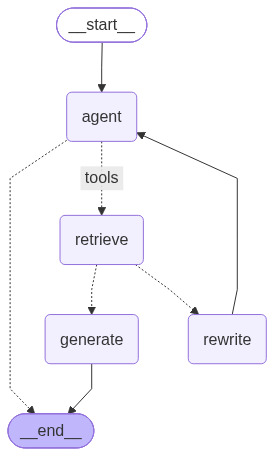

In [20]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool_langgraph,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [21]:
graph.invoke({"messages":"What is Langgraph?, tell me about it from the docs"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langgraph?, tell me about it from the docs', additional_kwargs={}, response_metadata={}, id='73e83250-37dc-44d7-a19c-190fd5d2a44a'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is Langgraph?, tell me about it from the docs". We need to answer using information from the docs. We have a tool to retrieve info about Langgraph via a vector DB blog. Let\'s search.', 'tool_calls': [{'id': 'fc_415a5cd9-8237-4a04-8463-df458a352b87', 'function': {'arguments': '{"query":"Langgraph documentation what is Langgraph"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 179, 'total_tokens': 264, 'completion_time': 0.180159475, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.008048129, 'prompt_tokens_details': None, 'queue_time': 0.29307339, 'total_time': 0.188207604}, 'model_name': 'openai/gpt-oss-120b', 'sy

In [22]:
graph.invoke({"messages":"What is Langchain?, tell me about it from the docs"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langchain?, tell me about it from the docs', additional_kwargs={}, response_metadata={}, id='78a49c69-cc64-4fae-84bc-c323decc5859'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is Langchain?, tell me about it from the docs". Need to provide explanation based on documentation. Should not fabricate, but can summarize. We can retrieve docs via tool. Use retriever_vector_langchain_blog with query "LangChain documentation overview".', 'tool_calls': [{'id': 'fc_e3d821ff-0fdf-4c8c-ab38-2fee16851c21', 'function': {'arguments': '{"query":"LangChain documentation overview"}', 'name': 'retriever_vector_langchain_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 179, 'total_tokens': 271, 'completion_time': 0.190942138, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.007751992, 'prompt_tokens_details': None, 'queue_time': 0.320809245

In [24]:
graph.invoke({"messages":"Explain What is Machine learning?, from the docs"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='Explain What is Machine learning?, from the docs', additional_kwargs={}, response_metadata={}, id='ee9035da-f7e9-4138-8354-c9f5e1378dbc'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Explain What is Machine learning?, from the docs". They want an explanation from the docs. Which docs? Possibly they refer to some documentation. Could be from Langchain or Langgraph docs? The system gave tools for searching Langgraph and Langchain blog. The user asks "Explain What is Machine learning?, from the docs". Could be generic. Use the tools to retrieve relevant docs. Let\'s search both.', 'tool_calls': [{'id': 'fc_e4688f74-39bc-4a5d-8b41-784ebce0ad8f', 'function': {'arguments': '{"query":"What is Machine learning?"}', 'name': 'retriever_vector_langchain_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 176, 'total_tokens': 298, 'completion_time': 0.258736931, 'comple